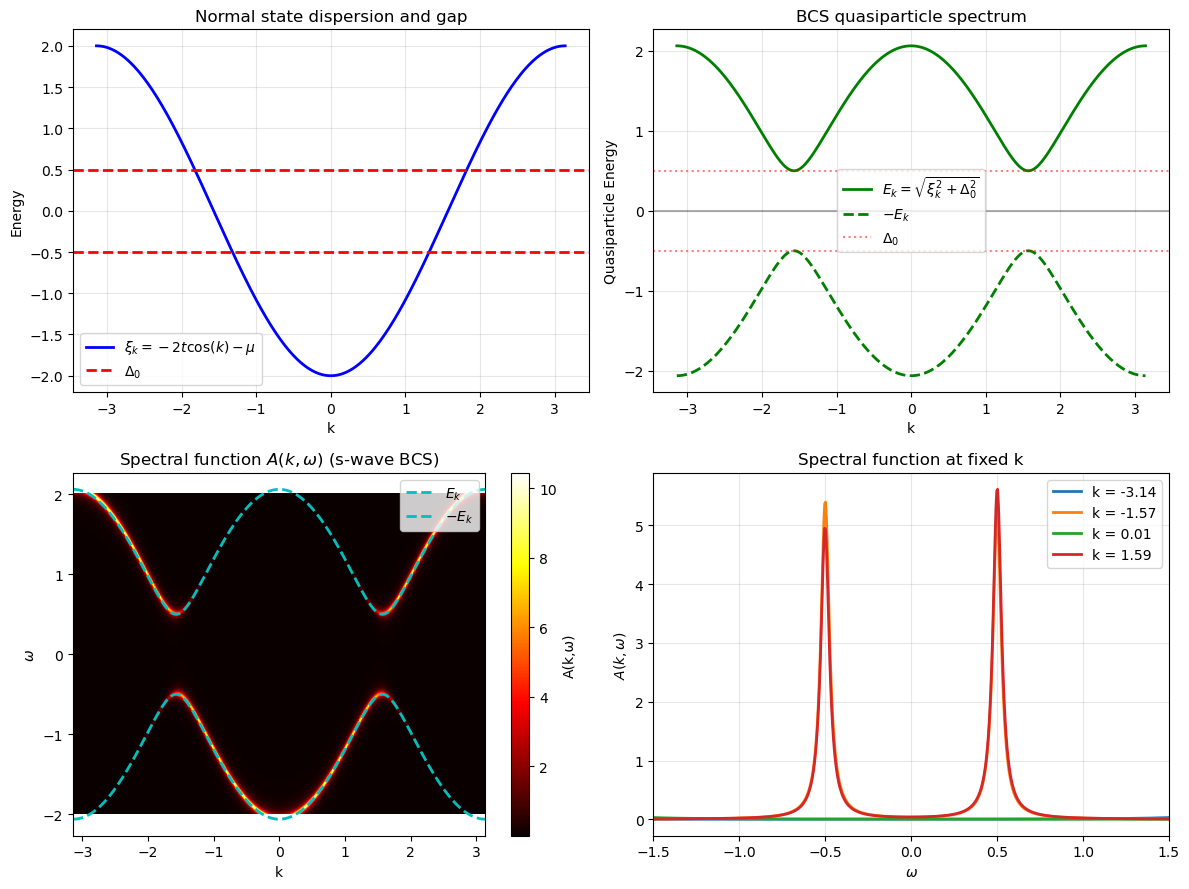


Density of States


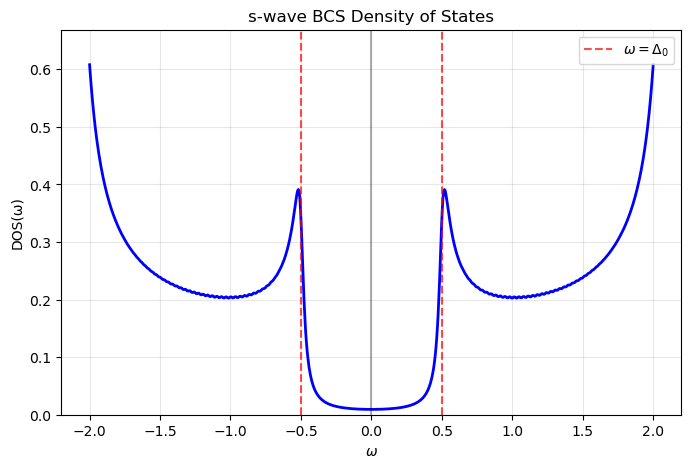

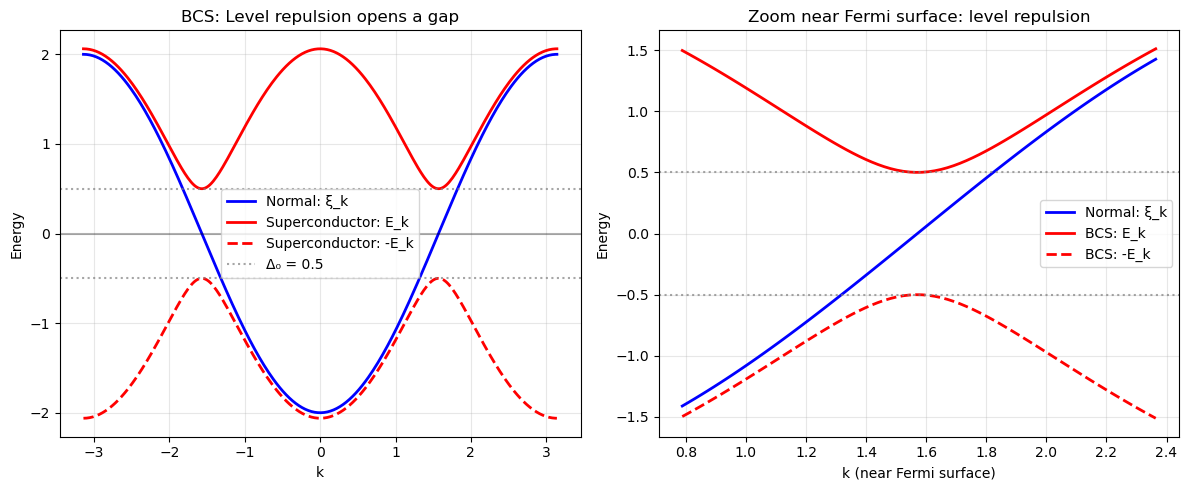


参数: t=1.0, μ=0.0, Δ0=0.5
能隙: 2Δ0 = 1.0
费米面位置: k_F = ±1.5708
在费米面处: ξ_k ≈ -0.010507
E_k = 0.500110
能隙 = 1.000221 ≈ 2Δ₀ = 1.0
相干因子: u² = 0.489, v² = 0.511


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bcs_spectral_function(k_vals, xi_k, Delta0, omega_vals, eta=0.01):
    """
    计算 s-wave BCS 平均场哈密顿量的谱函数 A(k, ω)
    
    s-wave: Δ_k = Δ0 (常数)
    
    参数:
        k_vals: k点数组
        xi_k: ξ_k = ε_k - μ
        Delta0: s-wave 超导能隙常数
        omega_vals: 频率网格
        eta: 展宽参数
    返回:
        A_kw: 谱函数数组 [len(k_vals), len(omega_vals)]
    """
    Ek = np.sqrt(xi_k**2 + Delta0**2)  # BCS 准粒子能量
    
    nk = len(k_vals)
    nw = len(omega_vals)
    A_kw = np.zeros((nk, nw))
    
    for ik in range(nk):
        E = Ek[ik]
        xi = xi_k[ik]
        
        # 相干因子
        u2 = 0.5 * (1 + xi/E)   # |u_k|^2
        v2 = 0.5 * (1 - xi/E)   # |v_k|^2
        
        for iw, w in enumerate(omega_vals):
            # 谱函数: A(k,ω) = u_k^2 δ(ω - E_k) + v_k^2 δ(ω + E_k)
            # 用洛伦兹展宽近似 delta 函数
            A_kw[ik, iw] = u2 * (eta/np.pi) / ((w - E)**2 + eta**2) + \
                           v2 * (eta/np.pi) / ((w + E)**2 + eta**2)
    
    return A_kw

# ============================================================
# 参数设置
# ============================================================
t = 1.0      # 跳跃积分
mu = 0.0     # 化学势 (半满)
Delta0 = 0.5 # s-wave 能隙常数
eta = 0.03   # 展宽

# k 空间离散化
nk = 300
k_vals = np.linspace(-np.pi, np.pi, nk)

# 能带 ε_k = -2t cos(k) (一维紧束缚模型)
epsilon_k = -2 * t * np.cos(k_vals)
xi_k = epsilon_k - mu

# 频率网格
omega_vals = np.linspace(-2.0, 2.0, 800)

# 计算谱函数
A_kw = bcs_spectral_function(k_vals, xi_k, Delta0, omega_vals, eta)

# ============================================================
# 绘图
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 图1: 能带 ξ_k 和能隙 Δ0
axes[0, 0].plot(k_vals, xi_k, 'b-', linewidth=2, label=r'$\xi_k = -2t\cos(k) - \mu$')
axes[0, 0].axhline(y=Delta0, color='r', linestyle='--', linewidth=2, label=r'$\Delta_0$')
axes[0, 0].axhline(y=-Delta0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Energy')
axes[0, 0].set_title('Normal state dispersion and gap')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 图2: 准粒子能谱 E_k = sqrt(ξ_k^2 + Δ0^2)
Ek = np.sqrt(xi_k**2 + Delta0**2)
axes[0, 1].plot(k_vals, Ek, 'g-', linewidth=2, label=r'$E_k = \sqrt{\xi_k^2 + \Delta_0^2}$')
axes[0, 1].plot(k_vals, -Ek, 'g--', linewidth=2, label=r'$-E_k$')
axes[0, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0, 1].axhline(y=Delta0, color='r', linestyle=':', alpha=0.5, label=r'$\Delta_0$')
axes[0, 1].axhline(y=-Delta0, color='r', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Quasiparticle Energy')
axes[0, 1].set_title('BCS quasiparticle spectrum')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 图3: 谱函数密度图 A(k, ω)
extent = [k_vals[0], k_vals[-1], omega_vals[0], omega_vals[-1]]
im = axes[1, 0].imshow(A_kw.T, origin='lower', extent=extent, aspect='auto', 
                       cmap='hot', interpolation='bilinear')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel(r'$\omega$')
axes[1, 0].set_title(r'Spectral function $A(k,\omega)$ (s-wave BCS)')
plt.colorbar(im, ax=axes[1, 0], label='A(k,ω)')

# 叠加准粒子能带
axes[1, 0].plot(k_vals, Ek, 'c--', linewidth=2, label=r'$E_k$')
axes[1, 0].plot(k_vals, -Ek, 'c--', linewidth=2, label=r'$-E_k$')
axes[1, 0].legend(loc='upper right')

# 图4: 特定 k 点的谱函数 cut
k_indices = [0, nk//4, nk//2, 3*nk//4]
for ik in k_indices:
    label = f'k = {k_vals[ik]:.2f}'
    axes[1, 1].plot(omega_vals, A_kw[ik], linewidth=2, label=label)
axes[1, 1].set_xlabel(r'$\omega$')
axes[1, 1].set_ylabel(r'$A(k,\omega)$')
axes[1, 1].set_title('Spectral function at fixed k')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([-1.5, 1.5])

plt.tight_layout()
plt.show()

# ============================================================
# 态密度 DOS(ω) = ∫ A(k,ω) dk/(2π)
# ============================================================
print("\n" + "=" * 60)
print("Density of States")
print("=" * 60)

dk = k_vals[1] - k_vals[0]

# 使用 np.trapezoid 替代 np.trapz (NumPy >= 2.0)
# 如果版本较低，也可以用 np.trapz 或自己实现
try:
    dos = np.trapezoid(A_kw, dx=dk, axis=0) / (2 * np.pi)
except AttributeError:
    # 旧版本 numpy 兼容
    try:
        dos = np.trapz(A_kw, dx=dk, axis=0) / (2 * np.pi)
    except AttributeError:
        # 手动实现梯形积分
        dos = (np.sum(A_kw, axis=0) - 0.5*(A_kw[0] + A_kw[-1])) * dk / (2 * np.pi)

plt.figure(figsize=(8, 5))
plt.plot(omega_vals, dos, 'b-', linewidth=2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'DOS(ω)')
plt.title('s-wave BCS Density of States')
plt.grid(alpha=0.3)
plt.axvline(x=Delta0, color='r', linestyle='--', alpha=0.7, label=r'$\omega = \Delta_0$')
plt.axvline(x=-Delta0, color='r', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.legend()
plt.ylim([0, max(dos)*1.1])
plt.show()

# ============================================================
# 验证 level repulsion
# ============================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_vals, xi_k, 'b-', linewidth=2, label='Normal: ξ_k')
plt.plot(k_vals, Ek, 'r-', linewidth=2, label='Superconductor: E_k')
plt.plot(k_vals, -Ek, 'r--', linewidth=2, label='Superconductor: -E_k')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axhline(y=Delta0, color='gray', linestyle=':', alpha=0.7, label=f'Δ₀ = {Delta0}')
plt.axhline(y=-Delta0, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('k')
plt.ylabel('Energy')
plt.title('BCS: Level repulsion opens a gap')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
mask = np.abs(k_vals - np.pi/2) < 0.8
k_near = k_vals[mask]
xi_near = xi_k[mask]
Ek_near = Ek[mask]

plt.plot(k_near, xi_near, 'b-', linewidth=2, label='Normal: ξ_k')
plt.plot(k_near, Ek_near, 'r-', linewidth=2, label='BCS: E_k')
plt.plot(k_near, -Ek_near, 'r--', linewidth=2, label='BCS: -E_k')
plt.axhline(y=Delta0, color='gray', linestyle=':', alpha=0.7)
plt.axhline(y=-Delta0, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('k (near Fermi surface)')
plt.ylabel('Energy')
plt.title('Zoom near Fermi surface: level repulsion')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 输出关键信息
# ============================================================
print(f"\n参数: t={t}, μ={mu}, Δ0={Delta0}")
print(f"能隙: 2Δ0 = {2*Delta0}")

# 找到费米面附近 k 的索引
if abs(mu/(2*t)) <= 1:
    k_F = np.arccos(-mu/(2*t))
    idx_F = np.argmin(np.abs(k_vals - k_F))
    print(f"费米面位置: k_F = ±{k_F:.4f}")
    print(f"在费米面处: ξ_k ≈ {xi_k[idx_F]:.6f}")
    print(f"E_k = {Ek[idx_F]:.6f}")
    print(f"能隙 = {2*Ek[idx_F]:.6f} ≈ 2Δ₀ = {2*Delta0}")
    print(f"相干因子: u² = {0.5*(1+xi_k[idx_F]/Ek[idx_F]):.3f}, v² = {0.5*(1-xi_k[idx_F]/Ek[idx_F]):.3f}")
else:
    print("费米面不在布里渊区内")